In [ ]:
# ── Cell 1: Install dependencies ──────────────────────────────────────────────
!pip -q install gdown tqdm yacs Cython scipy prefetch_generator imageio scikit-learn loguru
!pip -q uninstall -y opencv-python-headless opencv-contrib-python-headless
!pip -q install opencv-contrib-python-headless
!pip -q install pycocotools


  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 61.6/61.6 kB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 66.6/66.6 MB 12.8 MB/s eta 0:00:00


In [ ]:
# ── Cell 2: Mount Drive, clone YOLOPX, download weights ──────────────────────
from google.colab import drive
drive.mount("/content/drive")

!rm -rf /content/YOLOPX
!git clone -q https://github.com/jiaoZ7688/YOLOPX.git /content/YOLOPX
%cd /content/YOLOPX
!pip -q install -r requirements.txt
!mkdir -p weights
!gdown --id 1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z -O weights/epoch-195.pth
print("Repo + weights ready:", __import__("os").path.exists("weights/epoch-195.pth"))


Mounted at /content/drive
/content/YOLOPX
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 58.8/58.8 kB 5.2 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 87.5/87.5 kB 7.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.4/60.4 MB 16.2 MB/s eta 0:00:00
/usr/local/lib/python3.12/dist-packages/gdown/__main__.py:139: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From (original): https://drive.google.com/uc?id=1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z
From (redirected): https://drive.google.com/uc?id=1dlwaElu0dQQdoEeJkuP2LKGx1TSCjE-z&confirm=t&uuid=22c848c7-9d4b-4140-84b3-ac4364cbf885
To: /content/YOLOPX/weights/epoch-195.pth
100% 397M/397M [00:07<00:00, 53.6MB/s]
Repo + weights ready: True


In [ ]:
# ── Cell 3: Paths & experiment config ─────────────────────────────────────────
import os

DATA_DIR   = "/content/drive/MyDrive/delhi_dataset_yolopx_30fps"
ANN_FILE   = os.path.join(DATA_DIR, "default_instances.json")
IMG_DIR    = os.path.join(DATA_DIR, "images")

SKIP_RATES  = [1,3,5,10]
MODES       = ["copy_forward", "sparse_flow"]
DILATION_K  = 1
IMG_SIZE    = 640


In [ ]:
# ── Cell 4: Imports + all helper functions ────────────────────────────────────
import sys, time
import numpy as np
import cv2
import torch
import torch.nn.functional as F
import torchvision.transforms as transforms
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from tqdm import tqdm
from pycocotools.coco import COCO

sys.path.append("/content/YOLOPX")
from lib.config import cfg
from lib.models import get_net
from lib.dataset import LoadImages

import io

class SilentLoadImages:
    """Wraps LoadImages and suppresses its per-frame stdout print."""
    def __init__(self, *args, **kwargs):
        self._loader  = LoadImages(*args, **kwargs)
        self._iter    = None
        self._devnull = open(os.devnull, "w")

    def __len__(self):
        return len(self._loader)

    def __iter__(self):
        self._iter = iter(self._loader)   # ← this call sets self._loader.count = 0
        return self                        #   and all other internal state

    def __next__(self):
        old_stdout = sys.stdout
        sys.stdout = self._devnull
        try:
            return next(self._iter)        # ← delegates to the initialised iterator
        finally:
            sys.stdout = old_stdout        # always restore, even on StopIteration

    def __del__(self):
        self._devnull.close()

device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# Image normalisation transform
normalize = transforms.Normalize(mean=[0.485, 0.456, 0.406],
                                  std=[0.229, 0.224, 0.225])
transform  = transforms.Compose([transforms.ToTensor(), normalize])


# ── 1. Lane mask cleaner ─────────────────────────────────────────────────────
def clean_lane_mask(mask: np.ndarray) -> np.ndarray:
    mask = mask.astype(np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN,  np.ones((3, 3), np.uint8))
    mask = cv2.morphologyEx(mask, cv2.MORPH_CLOSE, np.ones((5, 5), np.uint8))
    n, labels, stats, _ = cv2.connectedComponentsWithStats(mask, connectivity=8)
    out = np.zeros_like(mask)
    for i in range(1, n):
        if stats[i, cv2.CC_STAT_AREA] >= 30:
            out[labels == i] = 255
    return out


# ── 2. Run model on a single tensor (GPU, with synchronize) ──────────────────
def run_model(img_tensor, img_det_shape, shapes):
    """Returns lane mask (H x W, uint8, 0 or 255). Caller must hold torch.no_grad()."""

    # ── FIX: ensure spatial dims are divisible by 32 ──────────────────
    _, _, h_in, w_in = img_tensor.shape
    new_h = (h_in // 32) * 32
    new_w = (w_in // 32) * 32
    if new_h != h_in or new_w != w_in:
        img_tensor = F.interpolate(
            img_tensor, size=(new_h, new_w),
            mode='bilinear', align_corners=False
        )
    # ──────────────────────────────────────────────────────────────────

    _, da, ll = model(img_tensor)
    _, _, H, W = img_tensor.shape          # now H and W are already aligned
    h, w = img_det_shape[:2]
    pw, ph   = int(shapes[1][1][0]), int(shapes[1][1][1])
    pl, pr   = pw // 2, pw - pw // 2
    pt, pb   = ph // 2, ph - ph // 2
    ll       = ll[:, :, pt:H-pb, pl:W-pr]
    ll       = F.interpolate(ll, (h, w), mode="bilinear", align_corners=False)
    _, ll    = torch.max(ll, 1)
    mask     = ll.int().squeeze().cpu().numpy().astype(np.uint8) * 255
    return clean_lane_mask(mask)


# ── 3. Sparse optical flow propagation (LK + affine warp) ───────────────────
def propagate_sparse(prev_gray: np.ndarray,
                     curr_gray: np.ndarray,
                     prev_mask: np.ndarray) -> np.ndarray:
    """
    Track ~200 corner points with Lucas-Kanade PyrLK,
    estimate a partial affine transform, warp the mask.
    Runs in ~5-12 ms on CPU at 720p — far cheaper than Farneback.
    Falls back to copy-forward if tracking fails.
    """
    pts = cv2.goodFeaturesToTrack(prev_gray, maxCorners=200,
                                   qualityLevel=0.01, minDistance=10,
                                   blockSize=5)
    if pts is None or len(pts) < 6:
        return prev_mask.copy()

    curr_pts, status, _ = cv2.calcOpticalFlowPyrLK(
        prev_gray, curr_gray, pts, None,
        winSize=(15, 15), maxLevel=2,
        criteria=(cv2.TERM_CRITERIA_EPS | cv2.TERM_CRITERIA_COUNT, 10, 0.03))

    good_p = pts[status.ravel() == 1]
    good_c = curr_pts[status.ravel() == 1]
    if len(good_p) < 6:
        return prev_mask.copy()

    M, _ = cv2.estimateAffinePartial2D(good_p, good_c,
                                        method=cv2.RANSAC,
                                        ransacReprojThreshold=3.0)
    if M is None:
        return prev_mask.copy()

    h, w = prev_mask.shape
    return cv2.warpAffine(prev_mask, M, (w, h),
                           flags=cv2.INTER_NEAREST,
                           borderMode=cv2.BORDER_CONSTANT, borderValue=0)


# ── 4. Dilation + metrics ────────────────────────────────────────────────────
def dilate_mask(mask: np.ndarray, k: int = 1) -> np.ndarray:
    kern = cv2.getStructuringElement(cv2.MORPH_ELLIPSE, (k, k))
    return cv2.dilate(mask, kern, iterations=1)


def compute_metrics(gt: np.ndarray, pred: np.ndarray) -> dict:
    gt   = (gt   > 0).astype(np.uint8)
    pred = (pred > 0).astype(np.uint8)
    tp   = np.logical_and(gt == 1, pred == 1).sum()
    tn   = np.logical_and(gt == 0, pred == 0).sum()
    fp   = np.logical_and(gt == 0, pred == 1).sum()
    fn   = np.logical_and(gt == 1, pred == 0).sum()
    eps  = 1e-7
    return dict(
        iou_lane = tp / (tp + fp + fn + eps),
        iou_bg   = tn / (tn + fp + fn + eps),
        miou     = (tp / (tp+fp+fn+eps) + tn / (tn+fp+fn+eps)) / 2,
        dice     = (2*tp) / (2*tp + fp + fn + eps),
        recall   = tp / (tp + fn + eps),
    )

print("All helpers defined.")


Device: cuda:0
All helpers defined.


In [ ]:
# Load model
model = get_net(cfg)
ckpt  = torch.load('/content/YOLOPX/weights/epoch-195.pth', map_location=device)
model.load_state_dict(ckpt['state_dict'], strict=True)
model = model.to(device).eval()

# ── FIX: only use half-precision if all layers support it ──────────────
USE_HALF = device.type == 'cuda'

if USE_HALF:
    try:
        model = model.half()
        # Test if it actually works
        with torch.no_grad():
            dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE).half().to(device)
            _ = model(dummy)
        print("✅ Running in float16 (half precision)")
    except RuntimeError:
        # Some layers can't handle half — fall back to float32
        model = model.float()
        USE_HALF = False
        print("⚠️  Half precision failed, falling back to float32")
else:
    print("ℹ️  Running on CPU in float32")

# Final warm-up pass
with torch.no_grad():
    dtype = torch.float16 if USE_HALF else torch.float32
    dummy = torch.zeros(1, 3, IMG_SIZE, IMG_SIZE, dtype=dtype).to(device)
    _ = model(dummy)

if device.type == 'cuda':
    torch.cuda.synchronize()

print("Model loaded and warmed up.")

✅ Running in float16 (half precision)
Model loaded and warmed up.


In [ ]:
# ── Cell 6: Pre-compute all GT masks (run once, reuse in sweep) ───────────────
coco         = COCO(ANN_FILE)
cats         = coco.loadCats(coco.getCatIds())
lane_cat_ids = [c["id"] for c in cats if "lane" in c["name"].lower()]
use_cat_ids  = lane_cat_ids if lane_cat_ids else coco.getCatIds()

img_ids_ordered = sorted(coco.getImgIds())
frame_meta      = []    # ordered list of {base, img_path}
gt_cache        = {}    # base_name -> gt mask (uint8, values 0/1)

print(f"Pre-computing GT masks for {len(img_ids_ordered)} frames...")
for img_id in tqdm(img_ids_ordered, leave=False):
    info    = coco.loadImgs(img_id)[0]
    base    = os.path.basename(info["file_name"])
    h, w    = info["height"], info["width"]
    mask    = np.zeros((h, w), dtype=np.uint8)
    ann_ids = coco.getAnnIds(imgIds=img_id, catIds=use_cat_ids)
    for ann in coco.loadAnns(ann_ids):
        mask = np.maximum(mask, coco.annToMask(ann).astype(np.uint8))
    gt_cache[base] = (mask * 255).astype(np.uint8)   # values 0 or 255  ← FIXED                            # values 0 or 1
    frame_meta.append({"base": base,
                       "img_path": os.path.join(IMG_DIR, base)})

print(f"Cached {len(gt_cache)} GT masks. Ready for sweep.")


loading annotations into memory...
Done (t=0.13s)
creating index...
index created!
Pre-computing GT masks for 3598 frames...


Cached 3598 GT masks. Ready for sweep.


In [ ]:
# Check what's actually in the annotation file
print("Total images in COCO:", len(coco.getImgIds()))
print("Total annotations:", len(coco.getAnnIds()))
print("All categories:", coco.loadCats(coco.getCatIds()))
print("lane_cat_ids found:", lane_cat_ids)
print("use_cat_ids:", use_cat_ids)

# Check a specific image
img_id = img_ids_ordered[0]
info = coco.loadImgs(img_id)[0]
print("\nFirst image:", info["file_name"])
ann_ids = coco.getAnnIds(imgIds=img_id)   # NO catId filter
print("Annotations (no filter):", len(ann_ids))
ann_ids_filtered = coco.getAnnIds(imgIds=img_id, catIds=use_cat_ids)
print("Annotations (with catId filter):", len(ann_ids_filtered))

# Show first annotation raw
if ann_ids:
    ann = coco.loadAnns(ann_ids)[0]
    print("\nFirst annotation:", ann)
    m = coco.annToMask(ann)
    print("Mask shape:", m.shape, "nonzero:", np.count_nonzero(m))

Total images in COCO: 3598
Total annotations: 14190
All categories: [{'id': 1, 'name': 'lane', 'supercategory': 'road'}]
lane_cat_ids found: [1]
use_cat_ids: [1]

First image: images/frame_00001.jpg
Annotations (no filter): 0
Annotations (with catId filter): 0


In [ ]:
#cell 7  ── Copy images from Drive to local /content/ (run once per session) ──────────
import shutil

LOCAL_IMG_DIR = "/content/frames"

if not os.path.exists(LOCAL_IMG_DIR) or len(os.listdir(LOCAL_IMG_DIR)) == 0:
    print("Copying frames from Drive to local storage...")
    shutil.copytree(IMG_DIR, LOCAL_IMG_DIR)
    print(f"Done. {len(os.listdir(LOCAL_IMG_DIR))} frames copied.")
else:
    print(f"Local frames already exist ({len(os.listdir(LOCAL_IMG_DIR))} files). Skipping copy.")

Local frames already exist (3598 files). Skipping copy.


In [ ]:
# ── Cell 7: Frame-skip sweep ──────────────────────────────────────────────────
sweep_results = []

for skip_rate in SKIP_RATES:
    for mode in MODES:

        # N=1 sparse_flow is identical to N=1 copy_forward — skip to save time
        if skip_rate == 1 and mode == "sparse_flow":
            print(f"skip={skip_rate}  mode={mode}  → skipped (identical to copy_forward)")
            continue

        print(f"\n▶  skip_rate={skip_rate}  mode={mode}")

        t_model_list = []   # seconds — keyframes only (0.0 for non-keyframes)
        t_prop_list  = []   # seconds — non-keyframes only (0.0 for keyframes)
        metric_rows  = []

        prev_gray = None
        prev_mask = None
        frame_idx = 0

        # ── Wall-clock starts HERE — includes LoadImages disk I/O ─────────────
        t_wall_start = time.perf_counter()

        for path, img, img_det, vid_cap, shapes in tqdm(
                SilentLoadImages(LOCAL_IMG_DIR, img_size=IMG_SIZE),
                total=len(frame_meta), leave=False):

            base_name  = Path(path).name
            img_tensor = transform(img).to(device)
            img_tensor = img_tensor.half() if USE_HALF else img_tensor.float()
            if img_tensor.ndimension() == 3:
                img_tensor = img_tensor.unsqueeze(0)
            curr_gray = (cv2.cvtColor(img_det, cv2.COLOR_BGR2GRAY)
                         if img_det.ndim == 3 else img_det.copy())

            is_keyframe = (frame_idx % skip_rate == 0) or (prev_mask is None)

            if is_keyframe:
                t0 = time.perf_counter()
                with torch.no_grad():
                    pred_mask = run_model(img_tensor, img_det.shape, shapes)
                if device.type == "cuda":
                    torch.cuda.synchronize()   # ← wait for GPU before reading clock
                t_model_list.append(time.perf_counter() - t0)
                t_prop_list.append(0.0)
            else:
                t0 = time.perf_counter()
                if mode == "copy_forward":
                    pred_mask = prev_mask.copy()
                else:  # sparse_flow
                    pred_mask = propagate_sparse(prev_gray, curr_gray, prev_mask)
                t_prop_list.append(time.perf_counter() - t0)
                t_model_list.append(0.0)

            prev_gray = curr_gray
            prev_mask = pred_mask

            # Evaluate against pre-cached GT (no extra disk I/O)
            if base_name in gt_cache:
                pred_d = dilate_mask(pred_mask, DILATION_K)
                m = compute_metrics(gt_cache[base_name], pred_d)
                m["is_keyframe"] = int(is_keyframe)
                metric_rows.append(m)

            frame_idx += 1

        # ── Wall-clock ends HERE ───────────────────────────────────────────────
        t_wall_total = time.perf_counter() - t_wall_start
        n_frames     = frame_idx
        n_kf         = sum(1 for i in range(n_frames) if i % skip_rate == 0)
        n_prop       = n_frames - n_kf

        # True effective FPS (wall clock includes I/O + inference + propagation)
        eff_fps_wall = n_frames / t_wall_total

        # Per-frame weighted averages (correct for stacked bar chart)
        avg_model_per_frame_ms = sum(t_model_list) / n_frames * 1000
        avg_prop_per_frame_ms  = sum(t_prop_list)  / n_frames * 1000

        # Per-event averages (for reporting: how long does one model call take?)
        model_nonzero = [t for t in t_model_list if t > 0]
        prop_nonzero  = [t for t in t_prop_list  if t > 0]
        avg_model_ms  = np.mean(model_nonzero) * 1000 if model_nonzero else 0.0
        avg_prop_ms   = np.mean(prop_nonzero)  * 1000 if prop_nonzero  else 0.0

        row = dict(
            skip_rate              = skip_rate,
            mode                   = mode,
            n_frames               = n_frames,
            n_keyframes            = n_kf,
            n_propagated           = n_prop,
            eff_fps                = round(eff_fps_wall, 1),
            total_wall_sec         = round(t_wall_total, 1),
            avg_model_ms           = round(avg_model_ms, 2),
            avg_prop_ms            = round(avg_prop_ms,  2),
            avg_model_per_frame_ms = round(avg_model_per_frame_ms, 2),
            avg_prop_per_frame_ms  = round(avg_prop_per_frame_ms,  2),
        )

        if metric_rows:
            df_m = pd.DataFrame(metric_rows)
            for col in ["iou_lane", "miou", "dice", "recall"]:
                row[col] = round(df_m[col].mean(), 4)
            kf_rows  = df_m[df_m["is_keyframe"] == 1]
            nkf_rows = df_m[df_m["is_keyframe"] == 0]
            row["iou_lane_kf"]   = round(kf_rows["iou_lane"].mean(),  4) if len(kf_rows)  else None
            row["iou_lane_prop"] = round(nkf_rows["iou_lane"].mean(), 4) if len(nkf_rows) else None

        sweep_results.append(row)
        print(f"   → {row['eff_fps']} FPS | wall={row['total_wall_sec']}s | "
              f"model={avg_model_ms:.1f} ms/call | prop={avg_prop_ms:.1f} ms/call | "
              f"iou_lane={row.get('iou_lane', 'N/A')} | miou={row.get('miou', 'N/A')}")


# ── Build final DataFrame ──────────────────────────────────────────────────────
df_sweep = pd.DataFrame(sweep_results)

# Only fill N=1 sparse_flow if N=1 copy_forward actually ran
rows_n1 = df_sweep[df_sweep["skip_rate"] == 1]
if len(rows_n1) > 0:
    row1 = rows_n1.iloc[0].copy()
    row1["mode"] = "sparse_flow"
    df_sweep = pd.concat([df_sweep, row1.to_frame().T], ignore_index=True)
else:
    print("⚠️  skip_rate=1 not in sweep — skipping sparse_flow fill-in")

df_sweep = df_sweep.sort_values(["skip_rate", "mode"]).reset_index(drop=True)

# ── Print summary table ────────────────────────────────────────────────────────
print("\n\n═══ SWEEP SUMMARY ═══")
show_cols = ["skip_rate", "mode", "eff_fps", "total_wall_sec",
             "avg_model_ms", "avg_prop_ms", "iou_lane", "miou"]
print(df_sweep[[c for c in show_cols if c in df_sweep.columns]].to_string(index=False))


RESULTDIR = "/content/drive/MyDrive/delhi_dataset_yolopx_30fps/results_yolopx"
os.makedirs(RESULTDIR, exist_ok=True)

sweep_csv = os.path.join(RESULTDIR, "framesweep_yolopx.csv")
df_sweep.to_csv(sweep_csv, index=False)
print(f"\nSaved to: {sweep_csv}")
print(df_sweep[["skip_rate", "mode", "eff_fps", "iou_lane", "miou"]].to_string(index=False))



▶  skip_rate=1  mode=copy_forward


   → 24.2 FPS | wall=148.6s | model=33.3 ms/call | prop=0.0 ms/call | iou_lane=0.4501 | miou=0.7165
skip=1  mode=sparse_flow  → skipped (identical to copy_forward)

▶  skip_rate=3  mode=copy_forward


   → 53.3 FPS | wall=67.6s | model=34.0 ms/call | prop=0.0 ms/call | iou_lane=0.4239 | miou=0.7027

▶  skip_rate=3  mode=sparse_flow


   → 42.0 FPS | wall=85.6s | model=34.3 ms/call | prop=7.2 ms/call | iou_lane=0.4246 | miou=0.703

▶  skip_rate=5  mode=copy_forward


   → 71.8 FPS | wall=50.1s | model=33.7 ms/call | prop=0.0 ms/call | iou_lane=0.405 | miou=0.6928

▶  skip_rate=5  mode=sparse_flow


   → 49.8 FPS | wall=72.2s | model=35.1 ms/call | prop=7.2 ms/call | iou_lane=0.403 | miou=0.6916

▶  skip_rate=10  mode=copy_forward


   → 92.5 FPS | wall=38.9s | model=35.7 ms/call | prop=0.0 ms/call | iou_lane=0.3737 | miou=0.6764

▶  skip_rate=10  mode=sparse_flow


   → 58.6 FPS | wall=61.4s | model=35.2 ms/call | prop=7.1 ms/call | iou_lane=0.3572 | miou=0.6673


═══ SWEEP SUMMARY ═══
skip_rate         mode eff_fps total_wall_sec avg_model_ms avg_prop_ms iou_lane    miou
        1 copy_forward    24.2          148.6        33.31         0.0   0.4501  0.7165
        1  sparse_flow    24.2          148.6        33.31         0.0   0.4501  0.7165
        3 copy_forward    53.3           67.6        33.96        0.03   0.4239  0.7027
        3  sparse_flow    42.0           85.6        34.34        7.23   0.4246   0.703
        5 copy_forward    71.8           50.1        33.72        0.03    0.405  0.6928
        5  sparse_flow    49.8           72.2         35.1        7.15    0.403  0.6916
       10 copy_forward    92.5           38.9        35.75        0.03   0.3737  0.6764
       10  sparse_flow    58.6           61.4        35.18        7.05   0.3572  0.6673

Saved to: /content/drive/MyDrive/delhi_dataset_yolopx_30fps/results_yolopx/frameswee

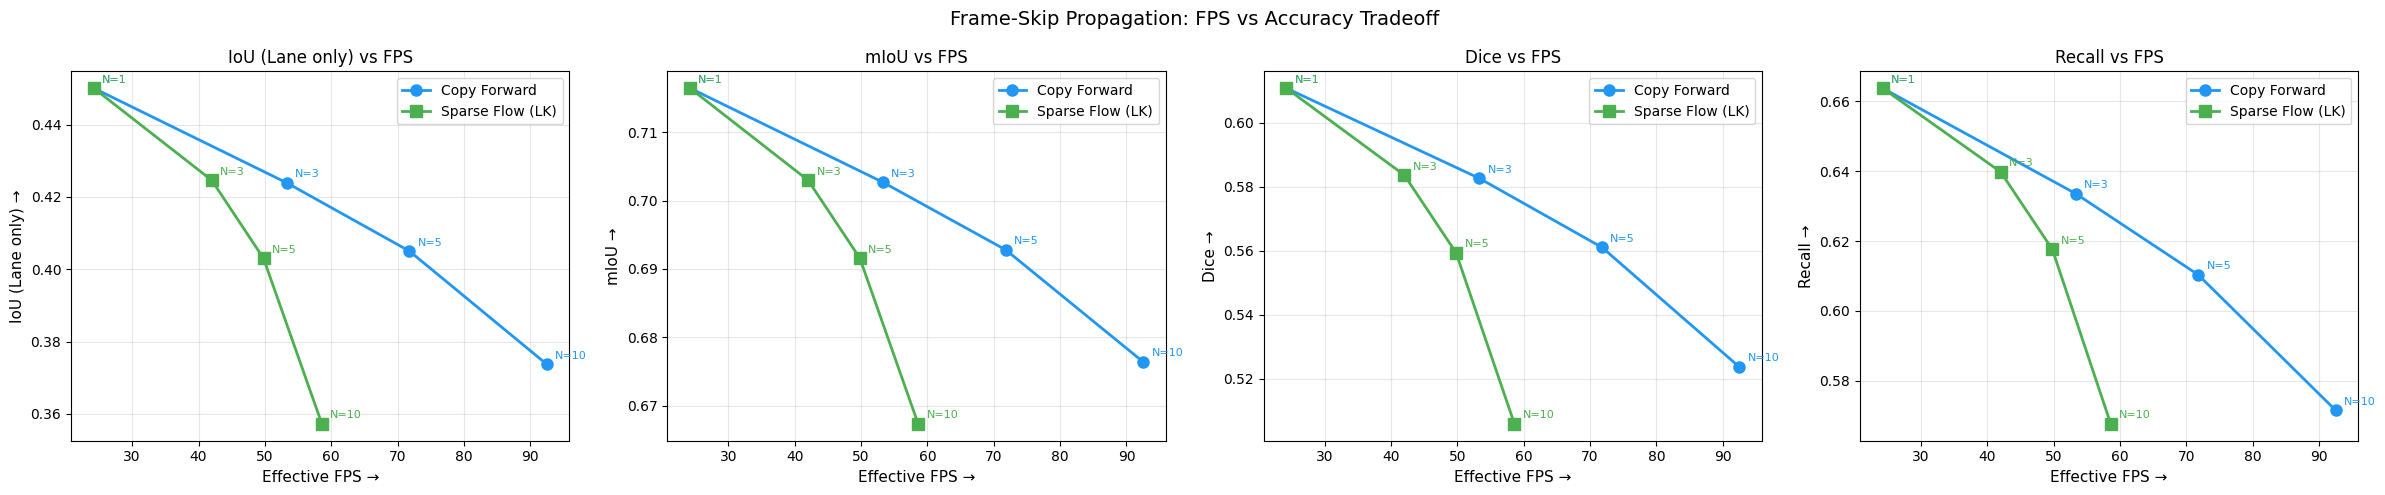

Plot saved.


In [ ]:
# ── Cell 8: Plot — FPS vs Accuracy tradeoff ───────────────────────────────────
COLORS  = {"copy_forward": "#2196F3", "sparse_flow": "#4CAF50"}
MARKERS = {"copy_forward": "o",       "sparse_flow": "s"}
LABELS  = {"copy_forward": "Copy Forward", "sparse_flow": "Sparse Flow (LK)"}

fig, axes = plt.subplots(1, 4, figsize=(24, 5))
fig.suptitle("Frame-Skip Propagation: FPS vs Accuracy Tradeoff", fontsize=14)

for ax, (col, label) in zip(axes, [("iou_lane", "IoU (Lane only)"),
                                     ("miou",     "mIoU"),
                                     ("dice",     "Dice"),
                                     ("recall",   "Recall")]):
    for mode in MODES:
        sub = df_sweep[df_sweep["mode"] == mode].sort_values("skip_rate")
        if col not in sub.columns:
            continue
        ax.plot(sub["eff_fps"], sub[col],
                color=COLORS[mode], marker=MARKERS[mode],
                linewidth=2, markersize=8, label=LABELS[mode])
        for _, r in sub.iterrows():
            ax.annotate(f"N={int(r['skip_rate'])}",
                        (r["eff_fps"], r[col]),
                        textcoords="offset points", xytext=(6, 4),
                        fontsize=8, color=COLORS[mode])
    ax.set_xlabel("Effective FPS →", fontsize=11)
    ax.set_ylabel(f"{label} →", fontsize=11)
    ax.set_title(f"{label} vs FPS")
    ax.legend()
    ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "fps_accuracy_tradeoff.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")

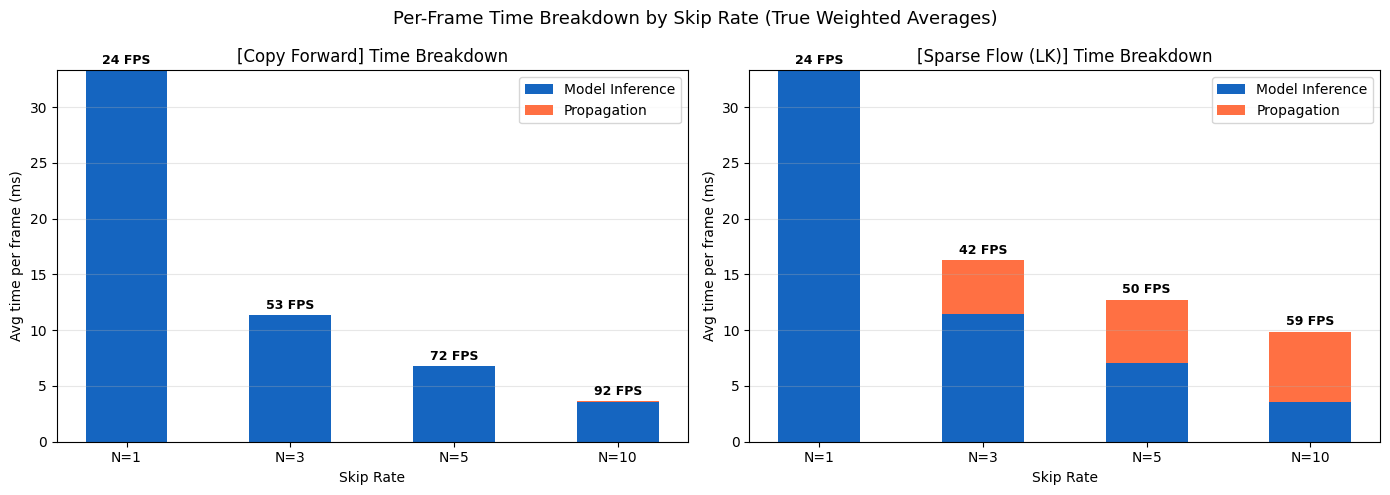

Plot saved.


In [ ]:
# ── Cell 9: Plot — Weighted per-frame timing breakdown ───────────────────────
# Uses weighted per-frame averages (not inflated per-event averages)
# so bar height == 1000 / eff_fps

fig2, axes2 = plt.subplots(1, 2, figsize=(14, 5))
fig2.suptitle("Per-Frame Time Breakdown by Skip Rate (True Weighted Averages)", fontsize=13)

for ax2, mode in zip(axes2, MODES):
    sub = df_sweep[df_sweep["mode"] == mode].sort_values("skip_rate")
    x   = np.arange(len(sub))
    w   = 0.5

    model_vals = sub["avg_model_per_frame_ms"].values.astype(float)
    prop_vals  = sub["avg_prop_per_frame_ms"].values.astype(float)

    ax2.bar(x, model_vals, width=w, label="Model Inference", color="#1565C0")
    ax2.bar(x, prop_vals,  width=w, label="Propagation",     color="#FF7043",
            bottom=model_vals)

    ax2.set_xticks(x)
    ax2.set_xticklabels([f"N={int(s)}" for s in sub["skip_rate"]])
    ax2.set_xlabel("Skip Rate")
    ax2.set_ylabel("Avg time per frame (ms)")
    ax2.set_title(f"[{LABELS[mode]}] Time Breakdown")
    ax2.legend()
    ax2.grid(axis="y", alpha=0.3)

    for i, (_, r) in enumerate(sub.iterrows()):
        bar_top = float(r["avg_model_per_frame_ms"]) + float(r["avg_prop_per_frame_ms"])
        ax2.text(i, bar_top + 0.3, f"{r['eff_fps']:.0f} FPS",
                 ha="center", va="bottom", fontsize=9, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(DATA_DIR, "timing_breakdown.png"), dpi=150, bbox_inches="tight")
plt.show()
print("Plot saved.")


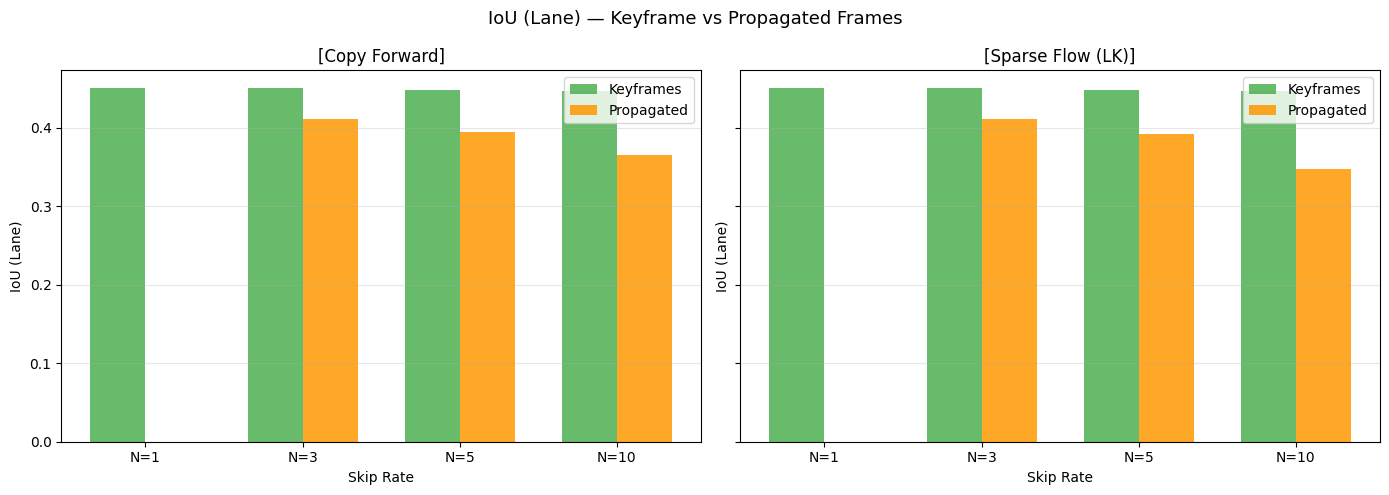

Plot saved.


In [ ]:
# ── Cell 10: Plot — Keyframe vs Propagated IoU (Lane) ────────────────────────
if "iou_lane_kf" in df_sweep.columns:
    fig3, axes3 = plt.subplots(1, 2, figsize=(14, 5), sharey=True)
    fig3.suptitle("IoU (Lane) — Keyframe vs Propagated Frames", fontsize=13)

    for ax3, mode in zip(axes3, MODES):
        sub = (df_sweep[df_sweep["mode"] == mode]
               .sort_values("skip_rate")
               .dropna(subset=["iou_lane_kf"]))
        x = np.arange(len(sub))
        w = 0.35
        ax3.bar(x - w/2, sub["iou_lane_kf"],   width=w,
                label="Keyframes",  color="#4CAF50", alpha=0.85)
        ax3.bar(x + w/2, sub["iou_lane_prop"],  width=w,
                label="Propagated", color="#FF9800", alpha=0.85)
        ax3.set_xticks(x)
        ax3.set_xticklabels([f"N={int(s)}" for s in sub["skip_rate"]])
        ax3.set_xlabel("Skip Rate")
        ax3.set_ylabel("IoU (Lane)")
        ax3.set_title(f"[{LABELS[mode]}]")
        ax3.legend()
        ax3.grid(axis="y", alpha=0.3)

    plt.tight_layout()
    plt.savefig(os.path.join(DATA_DIR, "keyframe_vs_propagated.png"),
                dpi=150, bbox_inches="tight")
    plt.show()
    print("Plot saved.")
else:
    print("iou_lane_kf column not found — skipping this plot.")
